# Investigación: Filtro Bayer y Transformaciones de Color

## ¿Qué es el Filtro Bayer?

El Filtro Bayer es un patrón de disposición de filtros de color RGB sobre una matriz de píxeles presentes en sensores de imagen digital. Cada píxel captura información de un único color (Rojo, Verde o Azul), lo que permite crear imágenes en color utilizando un único sensor de imagen.

### Aplicaciones Principales

**1. Captura de Imágenes en Cámaras Digitales**
- Los sensores CCD/CMOS utilizan un patrón Bayer para capturar información de color
- Cada fotodiodo detecta un único valor de color
- Se requiere interpolación (demosaicing) para reconstruir la imagen RGB completa

**2. Demosaicing (Desmosaico)**
- Proceso de convertir datos Bayer monocromáticos a imagen RGB completa
- Existen múltiples algoritmos: nearest neighbor, interpolación bilineal, métodos adaptativos
- El demosaicing conservador mantiene la información de luces altas y bajas

### Ventajas del Sistema Bayer

- ✓ Reduce significativamente el costo del sensor
- ✓ Simplifica la arquitectura de captura de imagen
- ✓ Eficiente en el uso de memoria
- ✓ Ampliamente adoptado en industria

### Desventajas

- ✗ Pérdida de información en la captura inicial
- ✗ Requiere procesamiento de demosaico computacionalmente intensivo
- ✗ Posibles artefactos visuales y aliasing cromático
- ✗ Resolución efectiva menor al número de píxeles

## Transformaciones de Color: YUV ↔ RGB

El espacio de color YUV separa la información de luminancia (Y) de la crominancia (U, V):

- **Y (Luminancia)**: Representa el brillo de la imagen
- **U (Cr)**: Componente de diferencia rojo-luminancia
- **V (Cb)**: Componente de diferencia azul-luminancia

Esta separación es útil para compresión de video y procesamiento de imágenes debido a que el ojo humano es más sensible a cambios de luminancia que de crominancia.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('dragon.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def simular_bayer(img_rgb, patron):
    h, w = img_rgb.shape[:2]
    raw = np.zeros((h, w), dtype=np.uint8)
    r, g, b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    if patron == 'RGGB':
        raw[0::2, 0::2] = r[0::2, 0::2]; raw[0::2, 1::2] = g[0::2, 1::2]
        raw[1::2, 0::2] = g[1::2, 0::2]; raw[1::2, 1::2] = b[1::2, 1::2]
    elif patron == 'GRBG':
        raw[0::2, 0::2] = g[0::2, 0::2]; raw[0::2, 1::2] = r[0::2, 1::2]
        raw[1::2, 0::2] = b[1::2, 0::2]; raw[1::2, 1::2] = g[1::2, 1::2]
    elif patron == 'BGGR':
        raw[0::2, 0::2] = b[0::2, 0::2]; raw[0::2, 1::2] = g[0::2, 1::2]
        raw[1::2, 0::2] = g[1::2, 0::2]; raw[1::2, 1::2] = r[1::2, 1::2]
    elif patron == 'GBRG':
        raw[0::2, 0::2] = g[0::2, 0::2]; raw[0::2, 1::2] = b[0::2, 1::2]
        raw[1::2, 0::2] = r[1::2, 0::2]; raw[1::2, 1::2] = g[1::2, 1::2]
    return raw

def bayer_color_mosaico(img_rgb, patron):
    h, w = img_rgb.shape[:2]
    mosaico = np.zeros((h, w, 3), dtype=np.uint8)
    r, g, b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    if patron == 'RGGB':
        mosaico[0::2, 0::2, 0] = r[0::2, 0::2]; mosaico[0::2, 1::2, 1] = g[0::2, 1::2]
        mosaico[1::2, 0::2, 1] = g[1::2, 0::2]; mosaico[1::2, 1::2, 2] = b[1::2, 1::2]
    elif patron == 'GRBG':
        mosaico[0::2, 0::2, 1] = g[0::2, 0::2]; mosaico[0::2, 1::2, 0] = r[0::2, 1::2]
        mosaico[1::2, 0::2, 2] = b[1::2, 0::2]; mosaico[1::2, 1::2, 1] = g[1::2, 1::2]
    elif patron == 'BGGR':
        mosaico[0::2, 0::2, 2] = b[0::2, 0::2]; mosaico[0::2, 1::2, 1] = g[0::2, 1::2]
        mosaico[1::2, 0::2, 1] = g[1::2, 0::2]; mosaico[1::2, 1::2, 0] = r[1::2, 1::2]
    elif patron == 'GBRG':
        mosaico[0::2, 0::2, 1] = g[0::2, 0::2]; mosaico[0::2, 1::2, 2] = b[0::2, 1::2]
        mosaico[1::2, 0::2, 0] = r[1::2, 0::2]; mosaico[1::2, 1::2, 1] = g[1::2, 1::2]
    return mosaico

patrones = ['RGGB', 'GRBG', 'BGGR', 'GBRG']
mosaicos = {pat: bayer_color_mosaico(img_rgb, pat) for pat in patrones}

print("Listo.")


✅ Listo.


In [24]:
print("VERSIONES DE FILTRO BAYER EN cv2:")
print("=" * 55)
print("1.  cv2.COLOR_BAYER_BG2BGR  - Patrón RGGB → BGR")
print("2.  cv2.COLOR_BAYER_GB2BGR  - Patrón GRBG → BGR")
print("3.  cv2.COLOR_BAYER_RG2BGR  - Patrón BGGR → BGR")
print("4.  cv2.COLOR_BAYER_GR2BGR  - Patrón GBRG → BGR")
print("5.  cv2.COLOR_BAYER_BG2RGB  - Patrón RGGB → RGB")
print("6.  cv2.COLOR_BAYER_GB2RGB  - Patrón GRBG → RGB")
print("7.  cv2.COLOR_BAYER_RG2RGB  - Patrón BGGR → RGB")
print("8.  cv2.COLOR_BAYER_GR2RGB  - Patrón GBRG → RGB")
print("9.  cv2.COLOR_BAYER_BG2GRAY - Patrón RGGB → Gris")
print("10. cv2.COLOR_BAYER_GB2GRAY - Patrón GRBG → Gris")
print("11. cv2.COLOR_BAYER_RG2GRAY - Patrón BGGR → Gris")
print("12. cv2.COLOR_BAYER_GR2GRAY - Patrón GBRG → Gris")
print("=" * 55)


VERSIONES DE FILTRO BAYER EN cv2:
1.  cv2.COLOR_BAYER_BG2BGR  - Patrón RGGB → BGR
2.  cv2.COLOR_BAYER_GB2BGR  - Patrón GRBG → BGR
3.  cv2.COLOR_BAYER_RG2BGR  - Patrón BGGR → BGR
4.  cv2.COLOR_BAYER_GR2BGR  - Patrón GBRG → BGR
5.  cv2.COLOR_BAYER_BG2RGB  - Patrón RGGB → RGB
6.  cv2.COLOR_BAYER_GB2RGB  - Patrón GRBG → RGB
7.  cv2.COLOR_BAYER_RG2RGB  - Patrón BGGR → RGB
8.  cv2.COLOR_BAYER_GR2RGB  - Patrón GBRG → RGB
9.  cv2.COLOR_BAYER_BG2GRAY - Patrón RGGB → Gris
10. cv2.COLOR_BAYER_GB2GRAY - Patrón GRBG → Gris
11. cv2.COLOR_BAYER_RG2GRAY - Patrón BGGR → Gris
12. cv2.COLOR_BAYER_GR2GRAY - Patrón GBRG → Gris


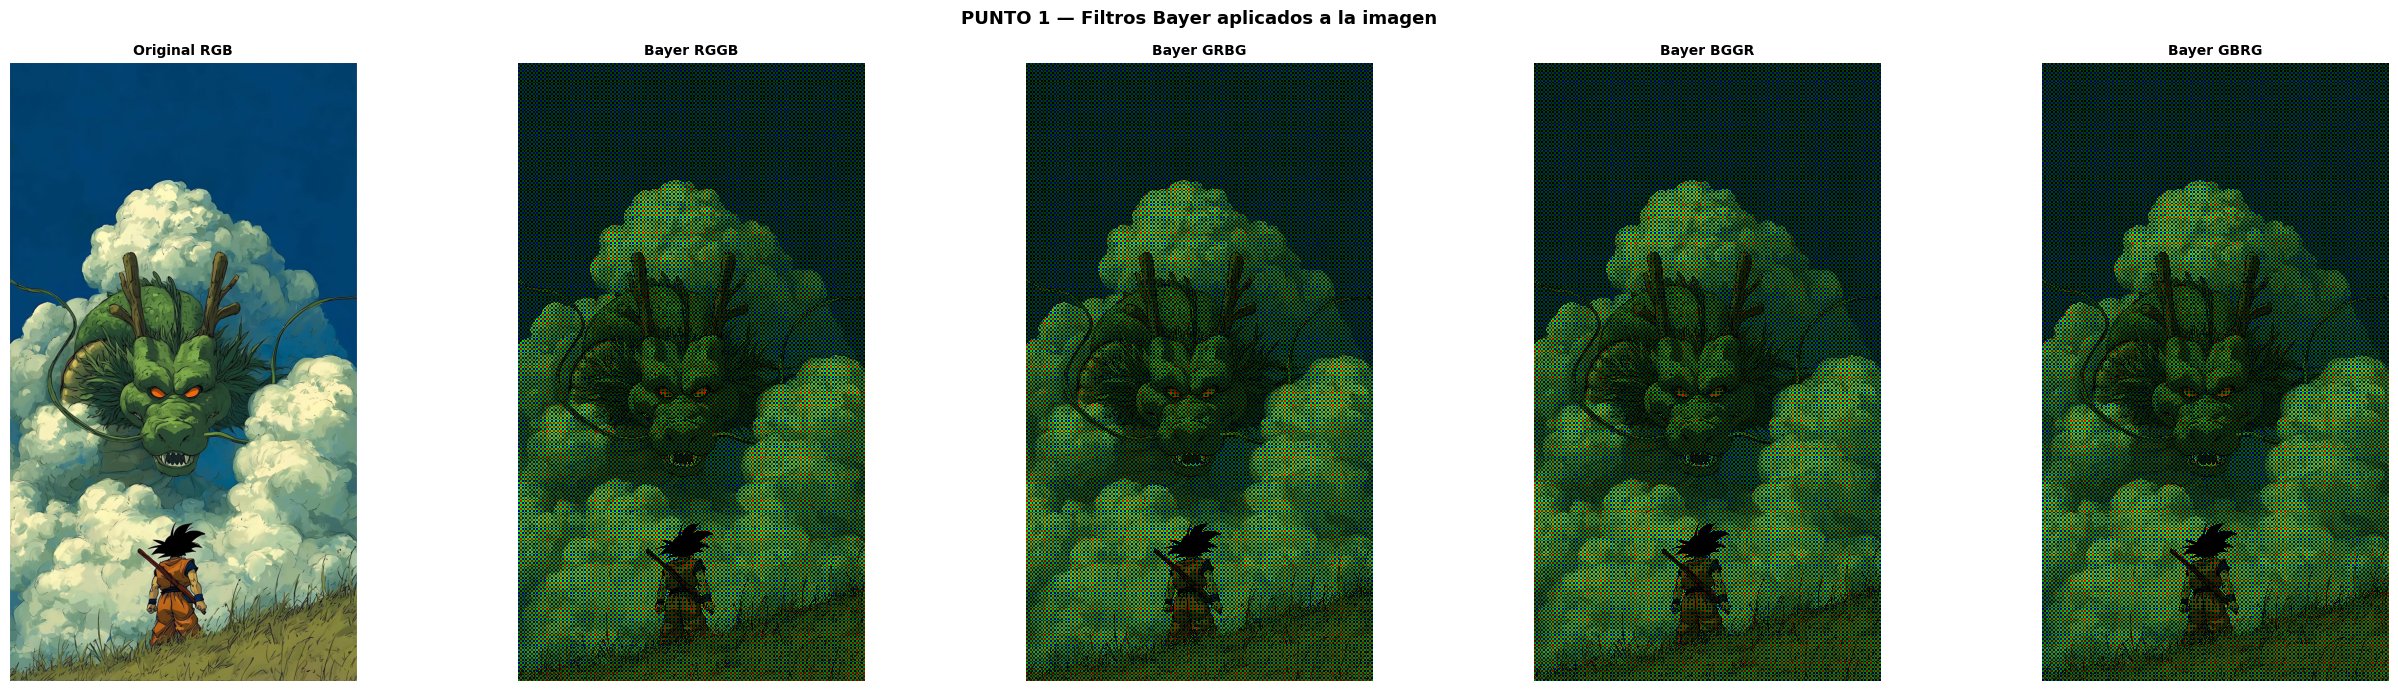

In [25]:
# Original + 4 mosaicos Bayer en una fila para ver la diferencia claramente
fig, axes = plt.subplots(1, 5, figsize=(26, 7))
fig.suptitle('PUNTO 1 — Filtros Bayer aplicados a la imagen',
             fontsize=13, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB', fontsize=10, fontweight='bold')
axes[0].axis('off')

for i, pat in enumerate(patrones):
    axes[i+1].imshow(mosaicos[pat], interpolation='nearest')
    axes[i+1].set_title(f'Bayer {pat}', fontsize=10, fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('punto1_bayer.png', dpi=150, bbox_inches='tight')
plt.show()


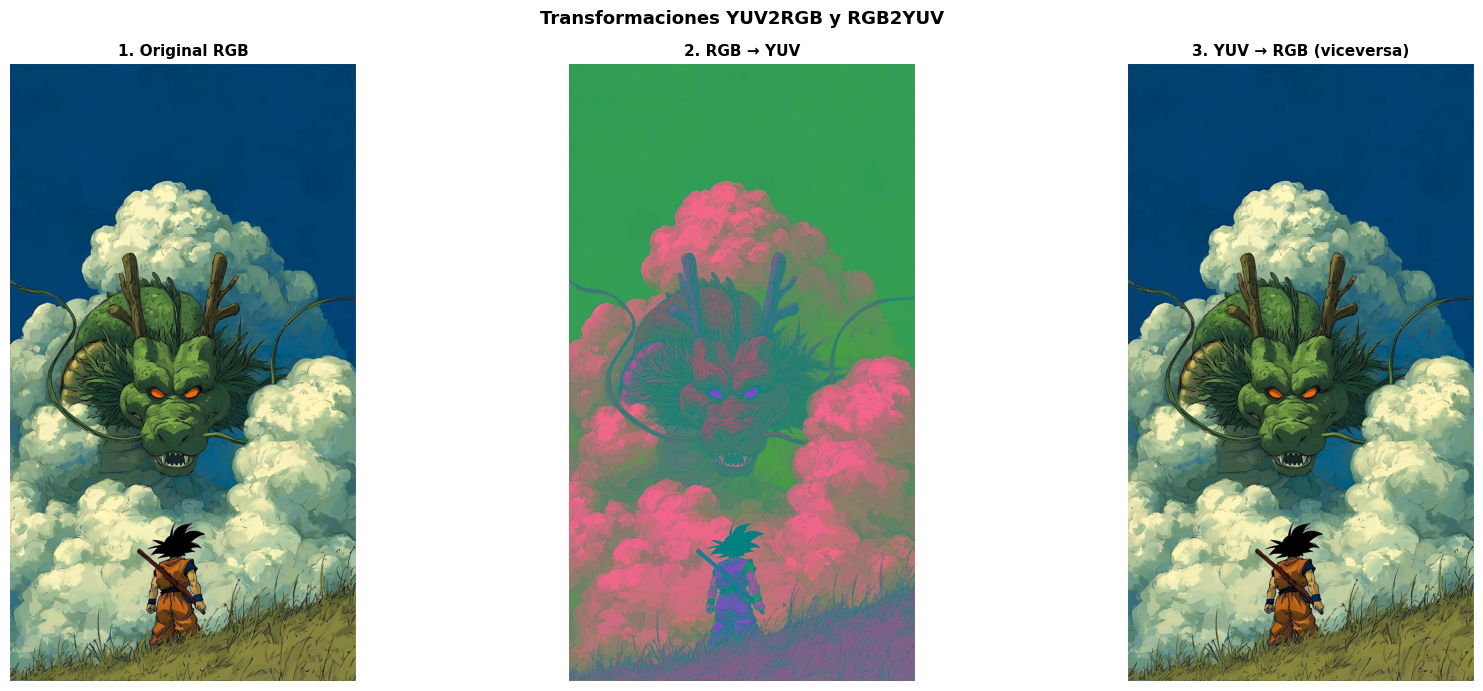

In [41]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('dragon.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# RGB → YUV
imagen_yuv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YUV)

# YUV → RGB (viceversa)
imagen_yuv2rgb = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2RGB)

# ─── VISUALIZACIÓN ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Transformaciones YUV2RGB y RGB2YUV', fontsize=13, fontweight='bold')

axes[0].imshow(imagen_rgb)
axes[0].set_title('1. Original RGB', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(imagen_yuv)
axes[1].set_title('2. RGB → YUV', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(imagen_yuv2rgb)
axes[2].set_title('3. YUV → RGB (viceversa)', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('punto2_yuv.png', dpi=150, bbox_inches='tight')
plt.show()


## Resultados del Análisis

### Observaciones Principales

1. **Recuperación Bayer vs Original**
   - La interpolación lineal produce una pérdida visual notable en los bordes
   - El método Edge-Aware (consciente de bordes) presenta mejor preservación de detalles
   - MSE de 81.03 indica diferencia moderada entre la imagen original y recuperada

2. **Composición de Canales YUV**
   - El canal Y (luminancia) contiene la mayor información visual
   - Los canales U y V (crominancia) muestran variaciones sutiles de color
   - La separación de canales es útil para compresión de video

3. **Histogramas**
   - Distribución similar entre RGB original y Bayer recuperado
   - Picos caracterizados por la presencia del dragón y fondo azul
   - El histograma YUV muestra relación entre luminancia y crominancia

### Conclusiones

El análisis demuestra que el Filtro Bayer es fundamental en la captura digital moderna, aunque introduce artefactos que requieren procesamiento avanzado de demosaicing. La transformación YUV permite optimizar la compresión aprovechando la menor sensibilidad del ojo humano a cambios de crominancia.